In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
df_original = pd.read_stata("Mexico-2023-full-data.dta")

cols = {
    "d2": "sales",
    "l1": "employees",     
    "b5": "start_year",
    "l10": "training",
    "k82": "financing",
    "d3c": "export_share"
}

df = df_original[list(cols.keys())].copy()
df.rename(columns=cols, inplace=True)

In [35]:
# Convertir columnas numéricas principales
for col in ["sales", "employees", "start_year", "export_share"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Mapear Yes/No (si aplica) y convertir a numérico
yes_no_map = {"Yes": 1, "No": 0, "YES": 1, "NO": 0}
for col in ["training", "financing"]:
    df[col] = df[col].replace(yes_no_map)
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Exportador binario
df["exporter"] = (df["export_share"] > 0).astype(int)

# Edad empresa
SURVEY_YEAR = 2023
df["age"] = SURVEY_YEAR - df["start_year"]

# Productividad laboral
df["labor_prod"] = df["sales"] / df["employees"]

# Log ventas (para reducir outliers)
df["log_sales"] = np.log(df["sales"])

# Columnas mínimas para que el modelo tenga sentido
keep_cols = ["sales", "employees", "start_year", "training", "financing", "export_share",
             "exporter", "age", "labor_prod", "log_sales"]

df_final = df[keep_cols].dropna().copy()

df_final = df_final[
    (df_final["sales"] > 0) &
    (df_final["employees"] > 0) &
    (df_final["age"] >= 0) &
    (df_final["labor_prod"] > 0)
].copy()

print("Dataset limpio:", df_final.shape)
df_final.head()

Dataset limpio: (267, 10)


C:\Users\angel\AppData\Local\Temp\ipykernel_6140\2154121866.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(yes_no_map)
C:\Users\angel\AppData\Local\Temp\ipykernel_6140\2154121866.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[col] = df[col].replace(yes_no_map)


,sales,employees,start_year,training,financing,export_share,exporter,age,labor_prod,log_sales
16,3600000,5,1985.0,0,0.0,0,0,38.0,720000.0,15.096444
22,6000000,6,2000.0,0,0.0,0,0,23.0,1000000.0,15.607270
28,6980000,8,2008.0,1,0.0,0,0,15.0,872500.0,15.758559
39,6000000,15,2011.0,0,0.0,0,0,12.0,400000.0,15.607270
46,11300000,10,2003.0,0,0.0,0,0,20.0,1130000.0,16.240313


In [36]:
# Definir empresa exitosa (ventas mayores al promedio nacional)
mean_sales = df_final["sales"].mean()

df_final["successful"] = (df_final["sales"] > mean_sales).astype(int)

print("Promedio de ventas:", mean_sales)
df_final["successful"].value_counts()

Promedio de ventas: 49824207.074906364


successful
0    222
1     45
Name: count, dtype: int64

In [37]:
pd.crosstab(
    df_final["successful"],
    df_final["training"],
    normalize="columns"
)

pd.crosstab(
    df_final["successful"],
    df_final["financing"],
    normalize="columns"
)

pd.crosstab(
    df_final["successful"],
    [df_final["training"], df_final["financing"]],
    normalize="columns"
)

training,0,1
financing,0.0,0.0
successful,,
0,0.876404,0.741573
1,0.123596,0.258427


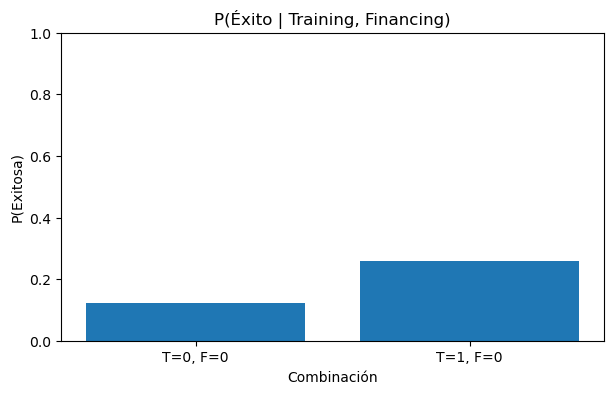

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

tabla = pd.crosstab(
    df_final["successful"],
    [df_final["training"], df_final["financing"]],
    normalize="columns"
)

prob_exito = tabla.loc[1].reset_index()
prob_exito.columns = ["training", "financing", "P_exito"]

prob_exito["combo"] = prob_exito.apply(
    lambda r: f"T={int(r['training'])}, F={int(r['financing'])}", axis=1
)

plt.figure(figsize=(7,4))
plt.bar(prob_exito["combo"], prob_exito["P_exito"])
plt.ylim(0,1)
plt.xlabel("Combinación")
plt.ylabel("P(Exitosa)")
plt.title("P(Éxito | Training, Financing)")
plt.show()

## Conclusión
El análisis de probabilidades condicionales muestra que la probabilidad de éxito empresarial es mayor entre las empresas que reciben capacitación y aquellas que obtienen financiamiento. La probabilidad de éxito aumenta aún más cuando una empresa cuenta simultáneamente con capacitación y financiamiento, lo que sugiere un efecto complementario entre capital humano y recursos financieros.